# Results

In [1]:
DATASET_PATH = "../dataset/bigcodebench_normalized.json"
OUT_PATH      = "../results/bigcodebench_llm_clones.json"
OLLAMA_MODEL = "llama3.1:latest"   

# Generation settings
LLM_OPTS = {
    "temperature": 0.6,
    "top_p": 0.95,
    "repeat_penalty": 1.05,
    "num_predict": 768,   
}

N_ENTRIES = 4
CLONES_PER_ENTRY = 2  

## Running tests

In [ ]:
import os, json
from src.utils import validate_with_unittest

# Load datasets
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)  # original dataset with tests
with open(OUT_PATH, "r", encoding="utf-8") as f:
    clone_data = json.load(f)  # dataset with clones

# Index original dataset by id for quick lookup
data_by_id = {entry["id"]: entry for entry in data}

results = []

# Iterate over clones dataset
for i, clone_entry in enumerate(clone_data, 1):
    entry_id = clone_entry["id"]
    print(f"\nTesting Entry {i}/{len(clone_data)} | id={entry_id}")

    if entry_id not in data_by_id:
        print(f"  ⚠️ No matching entry found for {entry_id}, skipping.")
        continue

    # Get the corresponding original entry
    entry = data_by_id[entry_id]
    tests_list = entry.get("test", [])

    clones_with_results = []
    for k, clone in enumerate(clone_entry.get("clones", []), 1):
        try:
            code = clone["code"]

            # Run unit tests on the clone
            test_results = validate_with_unittest(code, tests_list)
            clone["test_results"] = test_results

            # Print summary
            passed = sum(1 for v in test_results.values() if v == "PASS")
            total = len(test_results)
            print(f"  Clone {k}: {passed}/{total} tests passed")

        except Exception as e:
            print(f"  ❌ Error testing clone {k}: {e}")
            clone["test_results"] = {}

        clones_with_results.append(clone)

    # Add clones to original entry
    entry["clones"] = clones_with_results
    results.append(entry)

# Save dataset with test results
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
with open(OUT_PATH, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print(f"\n✅ Done. Saved dataset with test results to {OUT_PATH}")


## Calculating similarity scores

In [3]:
import json
from collections import Counter
from nltk.util import ngrams
import numpy as np
from codebleu import calc_codebleu
from src.similarity import tokenize_code, is_trivial_ngram

# === CONFIG ===
K = 500

# === Load dataset ===
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# === Build global ngram frequency (optional, if you need for filtering/trivial n-grams) ===
all_ngrams = []
for entry in dataset:
    tokens = tokenize_code(entry["original_code"])
    for n in range(1, 5):
        all_ngrams.extend(list(ngrams(tokens, n)))
    for clone in entry.get("clones", []):
        tokens = tokenize_code(clone["code"])
        for n in range(1, 5):
            all_ngrams.extend(list(ngrams(tokens, n)))

freq = Counter(all_ngrams)
most_common_dict = {
    ngram: 1 for ngram, _ in freq.most_common(K) if not is_trivial_ngram(ngram)
}

# === Compute CodeBLEU ===
labels, codebleu_scores = [], []

for entry in dataset:
    ref = entry["original_code"]
    for clone in entry.get("clones", []):
        hyp = clone["code"]
        labels.append(1)

        codebleu_score = calc_codebleu([ref], [hyp], lang="python")["codebleu"]
        codebleu_scores.append(codebleu_score)

        clone.setdefault("metrics", {})
        clone["metrics"].update({
            "codebleu": float(codebleu_score),
        })

# === Compute averages ===
print(f"Avg CodeBLEU: {np.mean(codebleu_scores):.4f}")

# === Save dataset ===
with open(OUT_PATH, "w", encoding="utf-8") as f:
    json.dump(dataset, f, indent=2)

Avg CodeBLEU: 0.3666


In [ ]:
# import json
# from collections import Counter
# from nltk.util import ngrams
# import numpy as np
# from crystalbleu import corpus_bleu
# from codebleu import calc_codebleu
# from nltk.translate.bleu_score import SmoothingFunction
# from src.similarity import tokenize_code, is_trivial_ngram
# import fractions

# # === CONFIG ===
# K = 500
# sm_func = SmoothingFunction(epsilon=0.0001).method1

# # === Patch Fraction for Python >=3.11 ===
# _OrigFraction_new = fractions.Fraction.__new__
# def fraction_new_patched(cls, *args, **kwargs):
#     kwargs.pop("_normalize", None)
#     return _OrigFraction_new(cls, *args, **kwargs)
# fractions.Fraction.__new__ = fraction_new_patched

# # === Load dataset ===
# with open(OUT_PATH, "r", encoding="utf-8") as f:
#     dataset = json.load(f)

# # === Build global ngram frequency ===
# all_ngrams = []
# for entry in dataset:
#     tokens = tokenize_code(entry["original_code"])
#     for n in range(1,5):
#         all_ngrams.extend(list(ngrams(tokens, n)))
#     for clone in entry.get("clones", []):
#         tokens = tokenize_code(clone["code"])
#         for n in range(1,5):
#             all_ngrams.extend(list(ngrams(tokens, n)))

# freq = Counter(all_ngrams)
# most_common_dict = {ngram:1 for ngram,_ in freq.most_common(K) if not is_trivial_ngram(ngram)}

# # === Compute BLEU / CrystalBLEU / CodeBLEU ===
# labels, bleu_scores, crystal_scores, codebleu_scores = [], [], [], []

# for entry in dataset:
#     ref = tokenize_code(entry["original_code"])
#     for clone in entry.get("clones", []):
#         hyp = tokenize_code(clone["code"])
#         labels.append(1)

#         bleu = corpus_bleu([ref], [hyp], smoothing_function=sm_func)
#         crystal = corpus_bleu([ref], [hyp], smoothing_function=sm_func, ignoring=most_common_dict)
#         codebleu_score = calc_codebleu([entry["original_code"]], [clone["code"]], lang="python")["codebleu"]

#         bleu_scores.append(bleu)
#         crystal_scores.append(crystal)
#         codebleu_scores.append(codebleu_score)

#         clone.setdefault("metrics", {})
#         clone["metrics"].update({
#             "bleu": float(bleu),
#             "crystalbleu": float(crystal),
#             "codebleu": float(codebleu_score),
#         })

# # === Compute averages ===
# print(f"Avg BLEU: {np.mean(bleu_scores):.4f}")
# print(f"Avg CrystalBLEU: {np.mean(crystal_scores):.4f}")
# print(f"Avg CodeBLEU: {np.mean(codebleu_scores):.4f}")

# # === Save dataset ===
# with open(OUT_PATH, "w", encoding="utf-8") as f:
#     json.dump(dataset, f, indent=2)

# # === Restore original Fraction to avoid side effects ===
# fractions.Fraction.__new__ = _OrigFraction_new

# print("✅ Finished scoring with BLEU, CrystalBLEU, and CodeBLEU.")


## Plotting

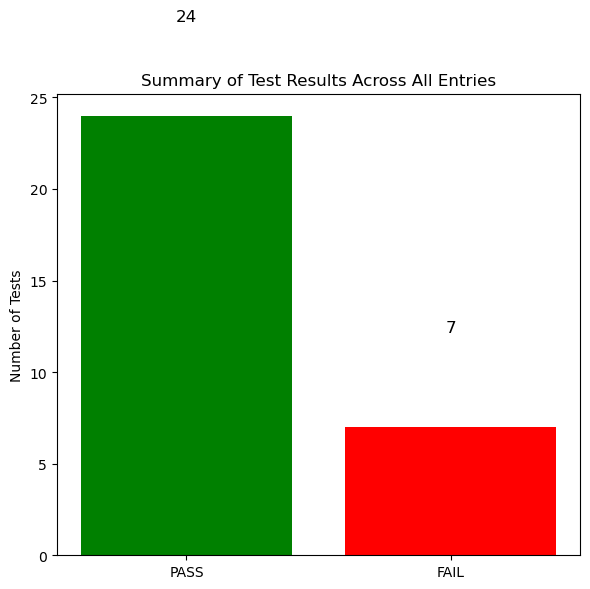

In [4]:
import json
import matplotlib.pyplot as plt

with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# === Count total PASS/FAIL ===
total_pass = 0
total_fail = 0

for entry in dataset:
    for clone in entry.get("clones", []):
        results = clone.get("test_results", {})
        for status in results.values():
            if status.upper() == "PASS":
                total_pass += 1
            elif status.upper() == "FAIL":
                total_fail += 1

# === Summary Plot ===
labels = ["PASS", "FAIL"]
counts = [total_pass, total_fail]
colors = ["green", "red"]

plt.figure(figsize=(6, 6))
plt.bar(labels, counts, color=colors)
plt.ylabel("Number of Tests")
plt.title("Summary of Test Results Across All Entries")
for i, count in enumerate(counts):
    plt.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

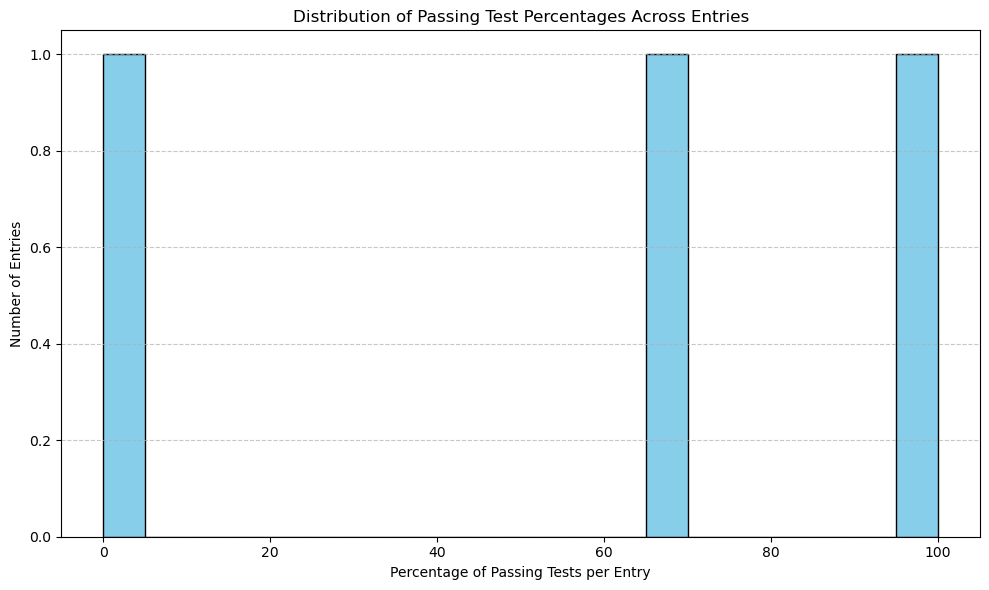

In [5]:
import json
import matplotlib.pyplot as plt

with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# === Compute passing percentage per entry ===
passing_percentages = []

for entry in dataset:
    total_tests = 0
    passed_tests = 0
    for clone in entry.get("clones", []):
        results = clone.get("test_results", {})
        total_tests += len(results)
        passed_tests += sum(1 for status in results.values() if status.upper() == "PASS")
    if total_tests > 0:
        passing_percentages.append(100 * passed_tests / total_tests)

# === Plot histogram ===
plt.figure(figsize=(10, 6))
plt.hist(passing_percentages, bins=20, color="skyblue", edgecolor="black")
plt.xlabel("Percentage of Passing Tests per Entry")
plt.ylabel("Number of Entries")
plt.title("Distribution of Passing Test Percentages Across Entries")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


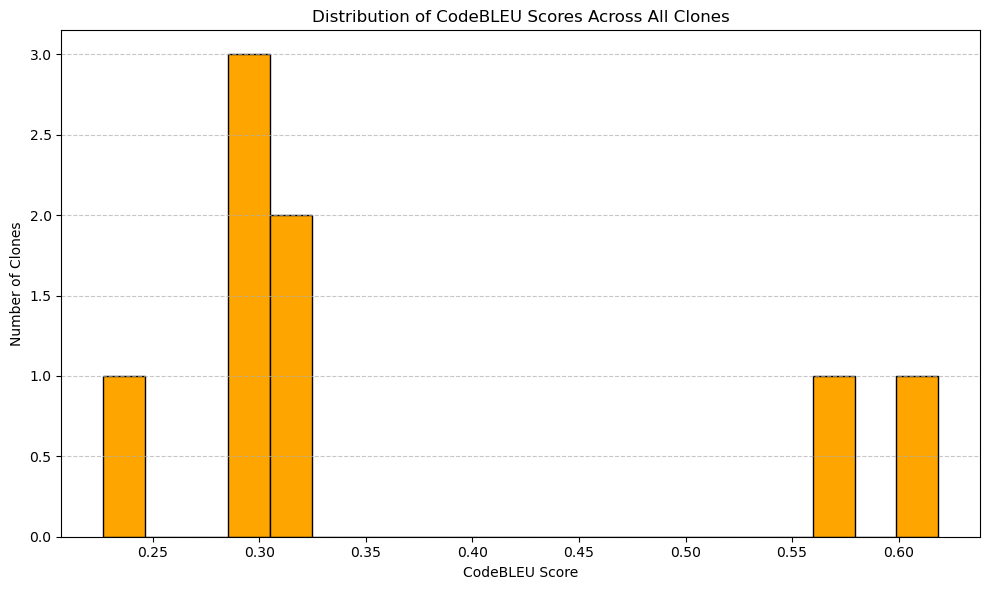

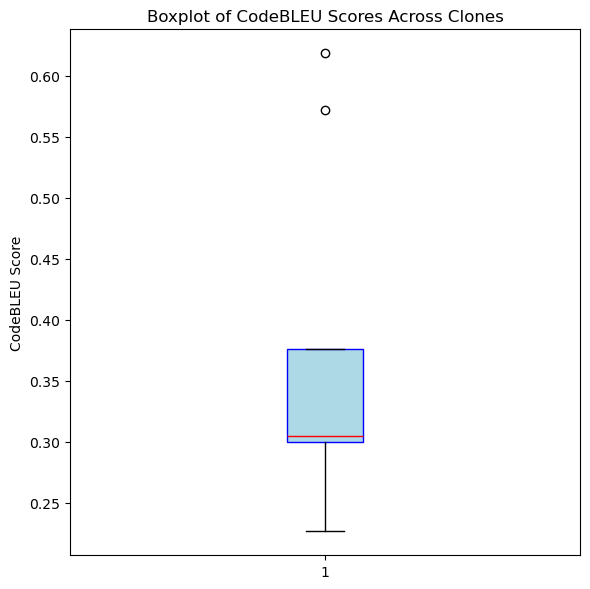

In [6]:
import json
import matplotlib.pyplot as plt

with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# === Collect all CodeBLEU scores ===
codebleu_scores = []

for entry in dataset:
    for clone in entry.get("clones", []):
        score = clone.get("metrics", {}).get("codebleu")
        if score is not None:
            codebleu_scores.append(score)

# === Histogram of CodeBLEU scores ===
plt.figure(figsize=(10, 6))
plt.hist(codebleu_scores, bins=20, color="orange", edgecolor="black")
plt.xlabel("CodeBLEU Score")
plt.ylabel("Number of Clones")
plt.title("Distribution of CodeBLEU Scores Across All Clones")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# === Boxplot of CodeBLEU scores ===
plt.figure(figsize=(6, 6))
plt.boxplot(codebleu_scores, vert=True, patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="blue"),
            medianprops=dict(color="red"))
plt.ylabel("CodeBLEU Score")
plt.title("Boxplot of CodeBLEU Scores Across Clones")
plt.tight_layout()
plt.show()


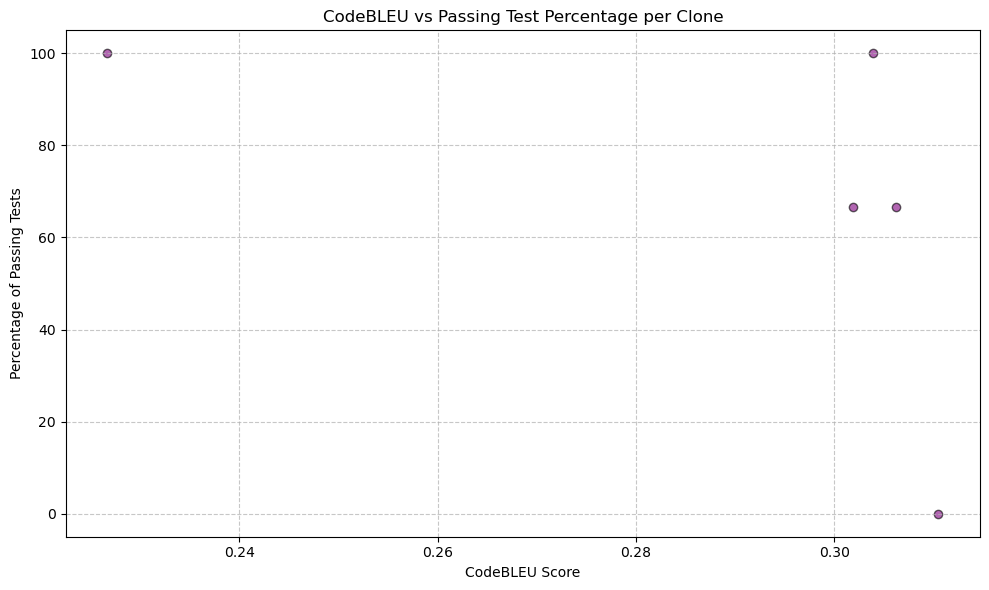

In [7]:
import json
import matplotlib.pyplot as plt

with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# === Collect per-clone passing percentage and CodeBLEU ===
passing_percentages = []
codebleu_scores = []

for entry in dataset:
    for clone in entry.get("clones", []):
        results = clone.get("test_results", {})
        total_tests = len(results)
        if total_tests == 0:
            continue
        passed_tests = sum(1 for status in results.values() if status.upper() == "PASS")
        passing_percentages.append(100 * passed_tests / total_tests)

        score = clone.get("metrics", {}).get("codebleu")
        codebleu_scores.append(score if score is not None else 0)

# === Scatter plot ===
plt.figure(figsize=(10, 6))
plt.scatter(codebleu_scores, passing_percentages, alpha=0.6, color="purple", edgecolor="black")
plt.xlabel("CodeBLEU Score")
plt.ylabel("Percentage of Passing Tests")
plt.title("CodeBLEU vs Passing Test Percentage per Clone")
plt.grid(linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()
